# MNIST coarse/local MST grid

Compare hierarchical IMSTE on a stratified sample of 8,000 MNIST images. The top row shows exact embeddings for 2, 3, 4, and 8 MST iterations; the rows below show the configured coarse/local grid.

In [ ]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

import sys
from pathlib import Path
from IPython.display import display

repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'mst_embedding').is_dir()),
    None,
)
if repo_root is not None:
    for path in (repo_root, repo_root / 'notebooks'):
        if str(path) not in sys.path:
            sys.path.insert(0, str(path))

from hierarchical_quality_utils import run_mnist_parameter_grid

# MNIST sample and reference graph.
N_INSTANCES = 8_000
DATA_SEED = 42
MODEL_SEED = 42
N_MSTS = 8
EXACT_MST_VALUES = (2, 3, 4, 8)
N_EPOCHS = 600
N_CLUSTERS = 100

# Rows are N_COARSE_MSTS; columns are N_LOCAL_MSTS.
N_COARSE_MSTS_VALUES = (2, 3, 4, 8)
N_LOCAL_MSTS_VALUES = (2, 3, 4, 8)
N_JOBS = -1

parameter_grid, exact_reference, embeddings, digit_labels, exact_embeddings = run_mnist_parameter_grid(
    coarse_mst_values=N_COARSE_MSTS_VALUES,
    local_mst_values=N_LOCAL_MSTS_VALUES,
    max_samples=N_INSTANCES,
    data_seed=DATA_SEED,
    model_seed=MODEL_SEED,
    n_msts=N_MSTS,
    exact_mst_values=EXACT_MST_VALUES,
    n_epochs=N_EPOCHS,
    n_clusters=N_CLUSTERS,
    n_jobs=N_JOBS,
)

display(exact_reference)
display(parameter_grid)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Fixed MNIST grid data: 8,000 samples × 784 features; coarse values=(2, 3, 4, 8); local values=(2, 3, 4, 8)


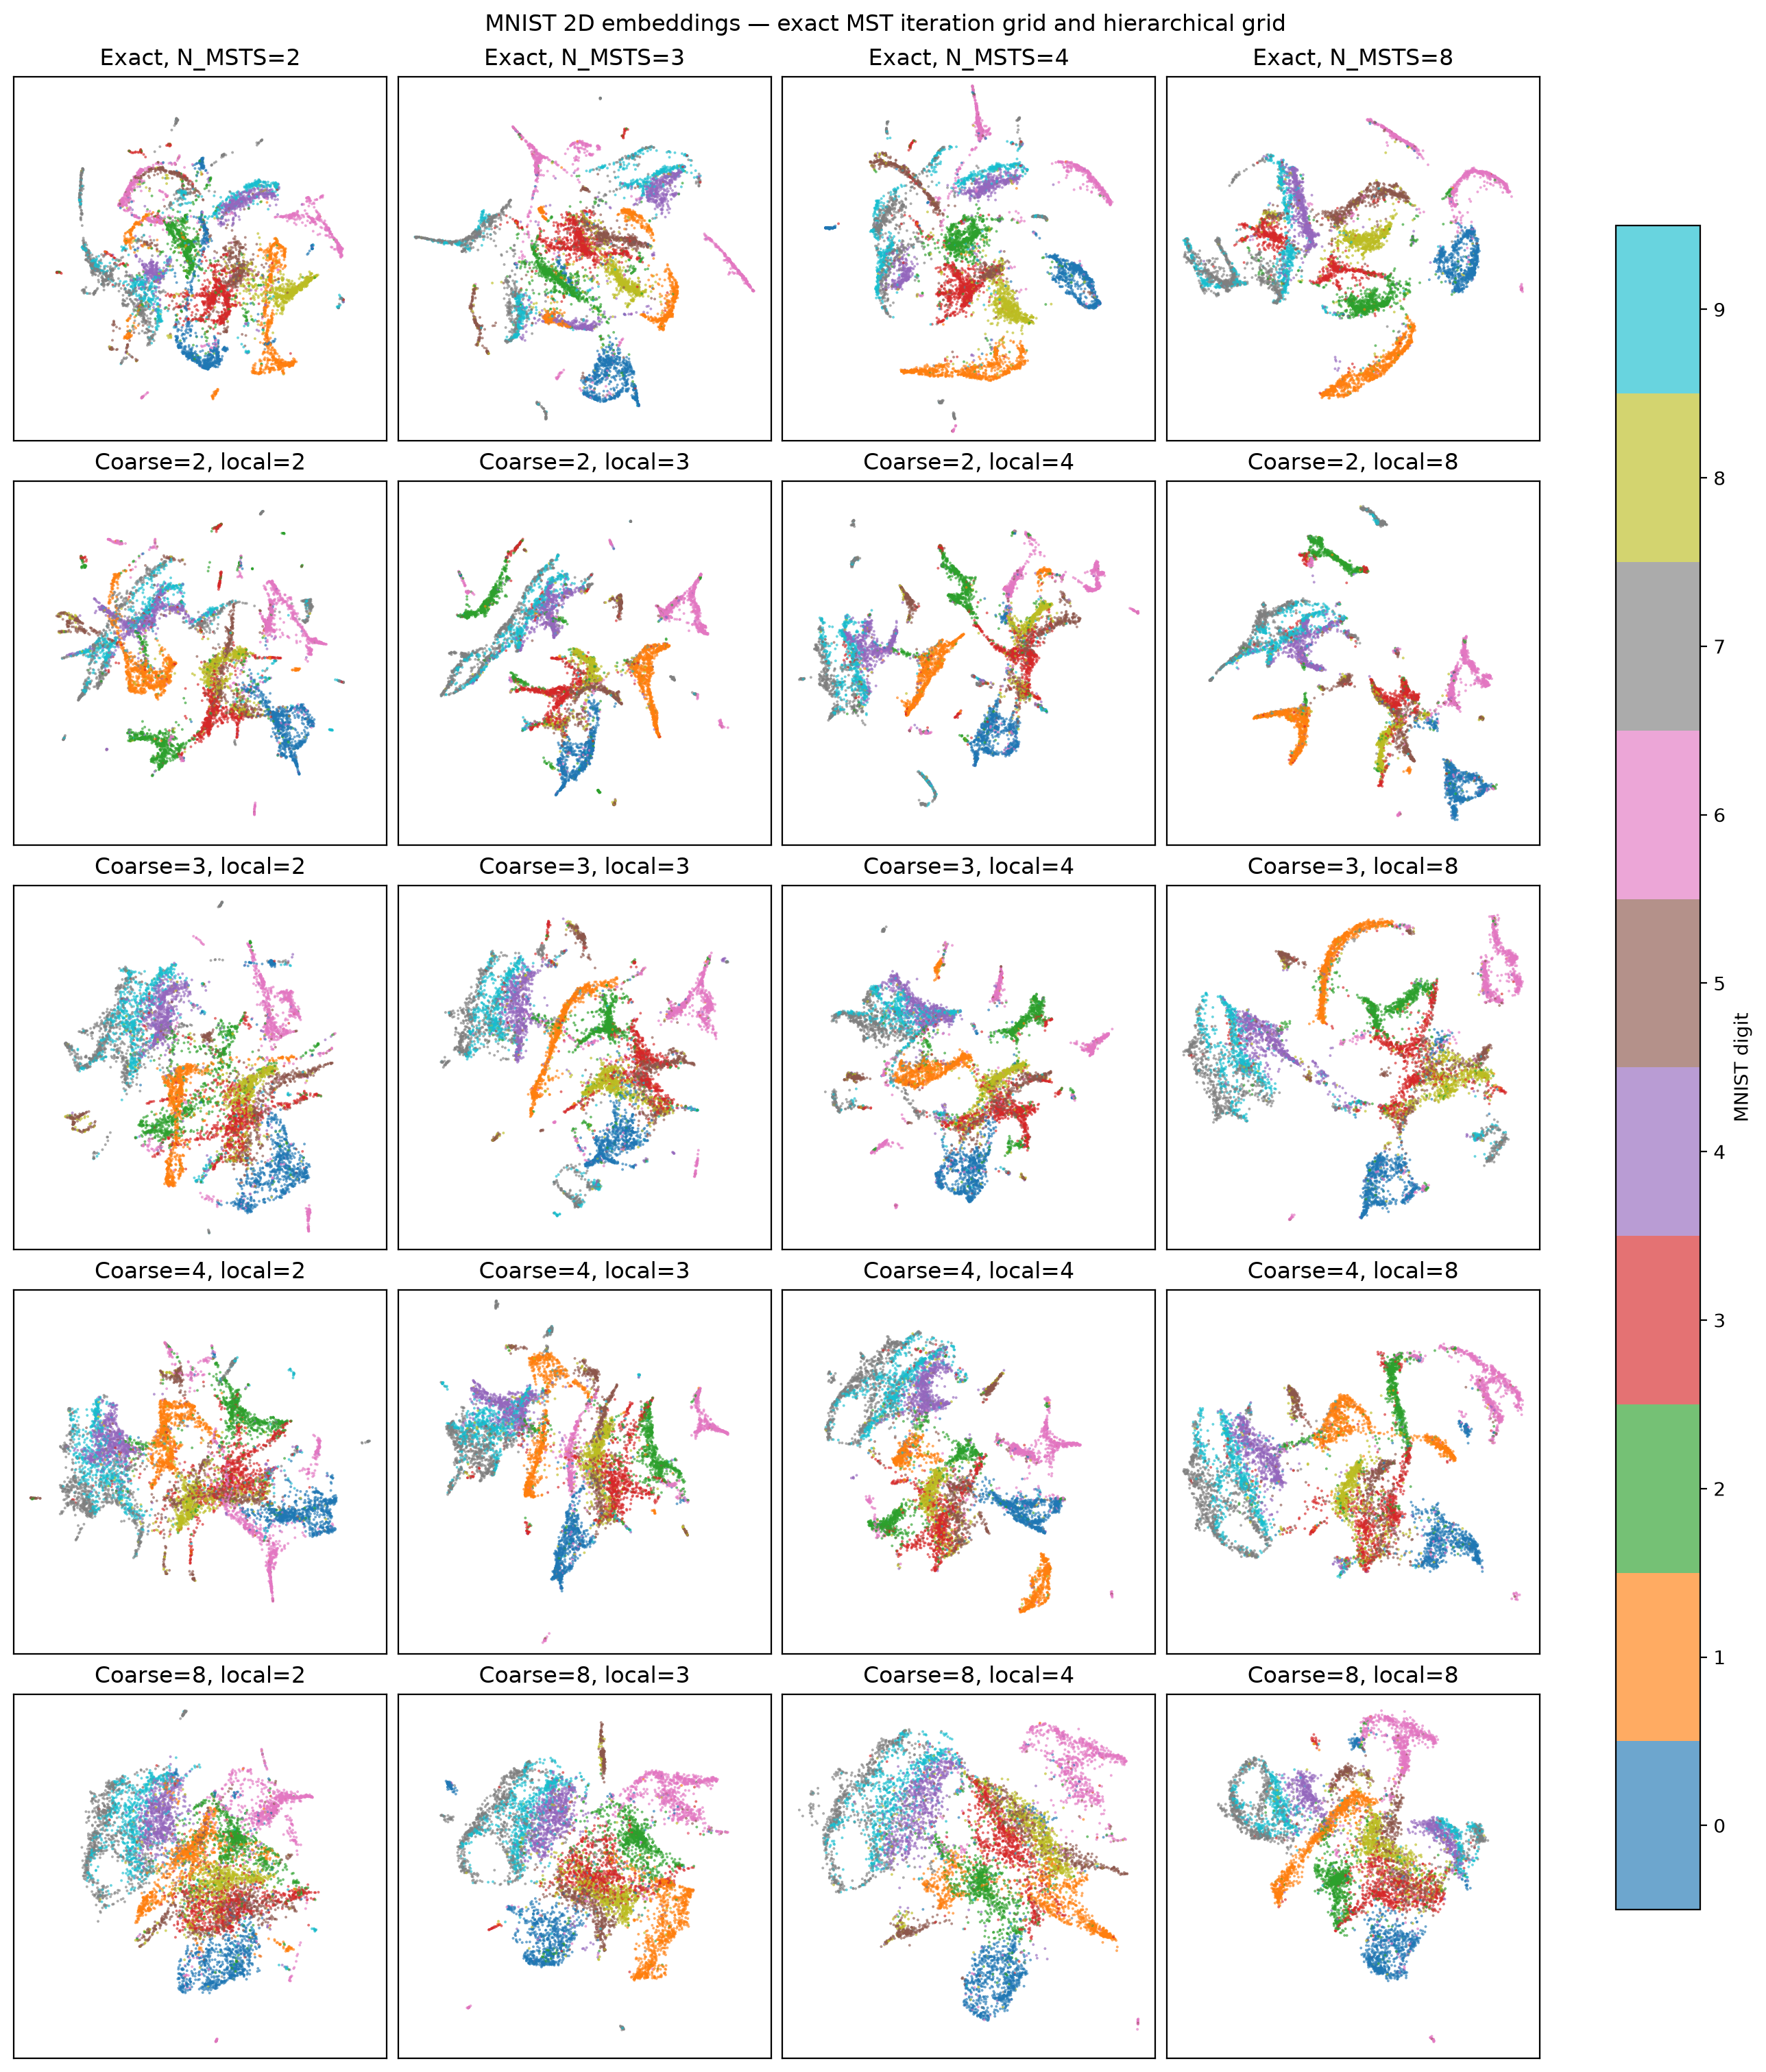

In [ ]:
from hierarchical_quality_utils import plot_mnist_embedding_grid

grid_figure = plot_mnist_embedding_grid(
    embeddings,
    digit_labels,
    exact_embeddings,
    coarse_mst_values=N_COARSE_MSTS_VALUES,
    local_mst_values=N_LOCAL_MSTS_VALUES,
)
grid_figure
